In [1]:
import torch
import matplotlib.pyplot as plt

from metashapes.shape import Ellipse, Cross, Star, Rectangle
from dispertorch import material, list_materials, ConstantEps

from metarcwa import Lattice, Layer, IsotropicMedium, Stack, PlaneWave, Model
from metarcwa.model.utils import from_metashapes, from_dispertorch

from metarcwa.solver.harmonics import reciprocal_lattice_vectors, reciprocal_index_map, harmonic_index_map, harmonic_wavevectors
from metarcwa.solver.homogeneous import homogeneous_modes

print("materials:", sorted(list_materials().keys()))

materials: ['Ag', 'Al', 'Au', 'Cu', 'Si3N4', 'SiO2', 'TiO2', 'aSi', 'cSi']


In [2]:
P = 400.0                 # square period (nm)
GRID = (128, 128)         # (Nx, Ny) real-space sampling
M, N = 20, 20               # Fourier truncation: |m|<=M (a1), |n|<=N (a2)
WL = torch.linspace(400, 800, 11)                # wavelength (nm)

# Create Lattice
lattice = Lattice.rectangular(P, P)

# Geometry (metashapes) — an anisotropic, rotated ellipse makes the TVF interesting
shape = Rectangle(center=torch.tensor([P / 2, P / 2]),
                size=torch.tensor([150.0, 90.0]),
                angle=torch.tensor(0.0))

# Materials (dispertorch): crystalline-Si inclusion in air
solid = material("aSi")
void  = ConstantEps(1.0)

solid_mat = IsotropicMedium(from_dispertorch(solid))
void_mat = IsotropicMedium(from_dispertorch(void))

layer = Layer(
        medium_solid=solid_mat,
        thickness=torch.tensor(200.0),
        medium_void=void_mat,
        shape_fn=from_metashapes(shape, soft=False, softness=1.0),
    )

stack = Stack(
    incidence=void_mat,
    layers=[layer],
    transmission=solid_mat,
    lattice=lattice,
)

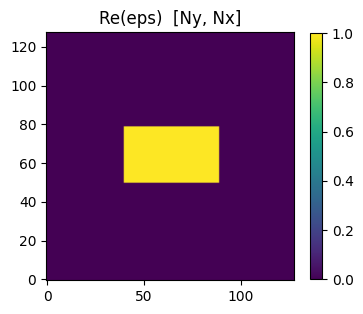

In [3]:
spec = stack.spec(WL, nx=GRID[0], ny=GRID[1])

a1, a2 = spec.a1, spec.a2
pattern = spec.layers[0].pattern

plt.figure(figsize=(4, 4))
plt.imshow(pattern.cpu(), origin="lower", cmap="viridis")
plt.title("Re(eps)  [Ny, Nx]"); plt.colorbar(shrink=0.8); plt.show()

In [5]:
pattern.shape

torch.Size([128, 128])

In [4]:
DTYPE = torch.float32
DEVICE = 'cuda:0'

# Build source
s_amp = 1.0
p_amp = 0.0
theta = 0.0
phi = 0.0

source = PlaneWave(WL, s_amp, p_amp, theta, phi)

# Create model
model = Model(stack, source)
model = model.to(dtype = DTYPE, device = DEVICE)
model_spec = model.spec(GRID[0], GRID[1])

# Get variables
kx0 = model_spec.kx0
ky0 = model_spec.ky0
a1 = model_spec.a1
a2 = model_spec.a2
eps_inc = model_spec.incidence.eps

# Compute kx and ky
b1, b2 = reciprocal_lattice_vectors(a1, a2)
m, n = harmonic_index_map(M, N, device=DEVICE)
Gx, Gy = reciprocal_index_map(m, n, b1, b2)
kx, ky = harmonic_wavevectors(kx0, ky0, Gx, Gy)
print(kx.dtype, kx.device, kx.shape)

torch.float32 cuda:0 torch.Size([11, 1, 1, 1681])


In [10]:
model_spec.layers

[PatternedLayer(thickness=tensor(200., device='cuda:0'), medium_solid=IsotropicMediumSpec(eps=tensor([13.3754+18.5070j, 16.9629+14.8375j, 18.4396+11.2445j, 18.7237+8.3480j,
         18.4432+6.1574j, 17.9272+4.5262j, 17.3328+3.3098j, 16.7325+2.3971j,
         16.1582+1.7087j, 15.6233+1.1889j, 15.1321+0.7981j], device='cuda:0')), medium_void=IsotropicMediumSpec(eps=tensor([1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j],
        device='cuda:0')), pattern=tensor([[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]], device='cuda:0'))]

In [5]:
# Compute modes and eigenvalues
lam, V = homogeneous_modes(eps_inc, kx, ky)


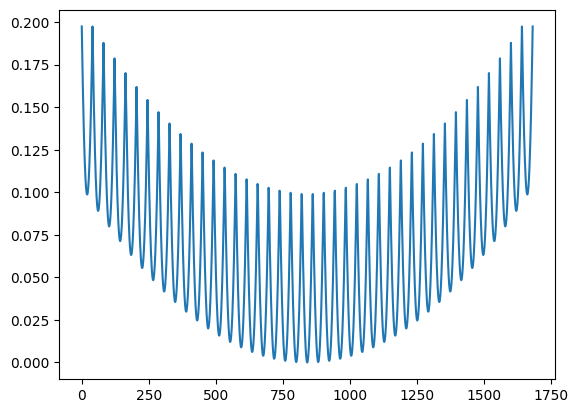

In [23]:
plt.plot((kx[0,0,0]**2 + ky[0,0,0]**2).cpu())

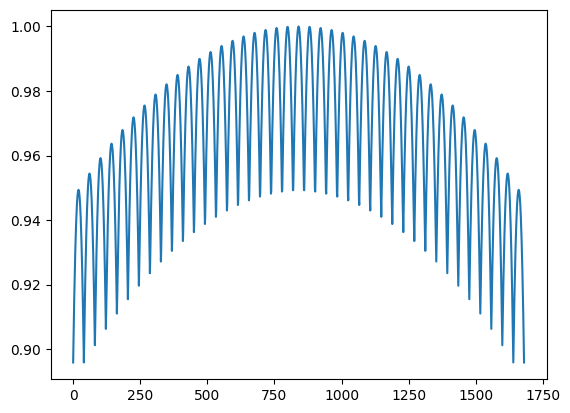

In [24]:
plt.plot((-1j*lam[0, 0, 0, :lam.shape[-1]//2]).real.cpu())

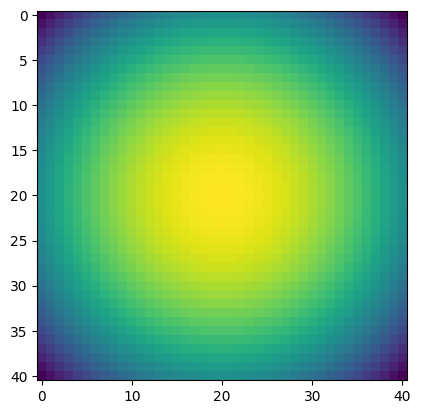

In [12]:
lam_one = lam[..., :lam.shape[-1]//2]

lam_new = lam_one.reshape([*lam_one.shape[:-1], 2*M+1, 2*N+1])

plt.imshow((-1j*lam_new[0, 0, 0, :,:]).real.cpu())